# YOLO26x Kaggle Training (2× T4)

Run on Kaggle with **Accelerator → GPU T4 x2**. Uses gradient accumulation to achieve effective batch 64 within T4 VRAM limits.

In [8]:
import os
import subprocess
import sys
from pathlib import Path

# ── Kaggle paths ──────────────────────────────────────────────────────────────
WORK_DIR = Path("/kaggle/working")
WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)

# Memory allocator fix — prevents OOM fragmentation on T4
os.environ["PYTORCH_ALLOC_CONF"]  = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["WANDB_DISABLED"]       = "true"
os.environ["OMP_NUM_THREADS"]      = "4"
os.environ["MKL_NUM_THREADS"]      = "4"

print("Working directory:", WORK_DIR)
print("Python           :", sys.version.split()[0])

# ── Install required packages ─────────────────────────────────────────────────
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "ultralytics", "roboflow", "python-dotenv"],
    check=True,
)

import torch
import ultralytics

torch.backends.cudnn.benchmark      = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32     = True
torch.set_float32_matmul_precision("high")

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout or result.stderr)

print("PyTorch version  :", torch.__version__)
print("Ultralytics      :", ultralytics.__version__)
print("CUDA available   :", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. Enable GPU T4 x2 in Kaggle Settings → Accelerator.")

GPU_COUNT   = torch.cuda.device_count()
GPU_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
print("GPU count        :", GPU_COUNT)
for i in range(GPU_COUNT):
    print(f"  GPU {i}          : {torch.cuda.get_device_name(i)}")
print("VRAM per GPU     :", round(GPU_VRAM_GB, 2), "GiB")
print("Total VRAM       :", round(GPU_VRAM_GB * GPU_COUNT, 2), "GiB")

if GPU_COUNT < 2:
    print("WARNING: Expected 2 GPUs. Set Accelerator to 'GPU T4 x2' in Kaggle settings.")


Working directory: /kaggle/working
Python           : 3.12.13
Thu Jun  4 12:26:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             34W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |          

## Paths And Dataset YAML

This cell finds or downloads the SYN-COCO Roboflow dataset and always writes the fixed YAML used by training.


In [9]:

from pathlib import Path
import json
import os
import random
import shutil
import yaml

WORK_DIR = Path("/kaggle/working")
os.chdir(WORK_DIR)

try:
    from dotenv import load_dotenv
    load_dotenv(WORK_DIR / "pipeline" / ".env")
except Exception:
    pass

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY", "7u4hrbsnMuzCMrIlSiiY").strip()
ROBOFLOW_WORKSPACE = "ayman-ccvba"
ROBOFLOW_PROJECT = "syn-coco-omar-z5pz7"
ROBOFLOW_VERSION = 1
DATASET_DIR = WORK_DIR / "syn-coco-omar-z5pz7-1"
ROBOFLOW_FORMAT = "yolo26"

ORIGINAL_YAML = DATASET_DIR / "data.yaml"
FIXED_YAML = DATASET_DIR / "data_fixed.yaml"
SPLIT_DATASET_DIR = DATASET_DIR / "split_80_10_10"
SPLIT_MANIFEST = SPLIT_DATASET_DIR / "split_manifest.json"


def find_dataset_dir() -> Path | None:
    preferred = [DATASET_DIR, WORK_DIR / "syn-coco-omar-z5pz7-1", WORK_DIR / "syn-coco-omar-z5pz7"]
    for path in preferred:
        if (path / "data.yaml").exists():
            return path.resolve()

    ignored = {".cache", ".conda", ".config", ".codex", ".local", ".vscode-server", "YOLO26", "coco_val2017_yolo_REAL"}
    for child in sorted(WORK_DIR.iterdir()):
        if not child.is_dir() or child.name in ignored or child.name.startswith("."):
            continue
        if (child / "data.yaml").exists():
            return child.resolve()
        for grandchild in sorted(child.iterdir()):
            if grandchild.is_dir() and (grandchild / "data.yaml").exists():
                return grandchild.resolve()
    return None


def download_syn_coco_dataset() -> Path:
    from roboflow import Roboflow

    if not ROBOFLOW_API_KEY:
        raise RuntimeError("ROBOFLOW_API_KEY env var is required to download from Roboflow.")
    print("SYN-COCO data.yaml was not found; downloading Roboflow dataset into:", DATASET_DIR)
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    version = project.version(ROBOFLOW_VERSION)
    dataset = version.download(ROBOFLOW_FORMAT, location=str(DATASET_DIR), overwrite=False)
    return Path(dataset.location).resolve()


def ensure_syn_coco_dataset() -> Path:
    global DATASET_DIR, ORIGINAL_YAML, FIXED_YAML, SPLIT_DATASET_DIR, SPLIT_MANIFEST

    found = find_dataset_dir()
    if found is None:
        found = download_syn_coco_dataset()

    DATASET_DIR = found
    ORIGINAL_YAML = DATASET_DIR / "data.yaml"
    FIXED_YAML = DATASET_DIR / "data_fixed.yaml"
    SPLIT_DATASET_DIR = DATASET_DIR / "split_80_10_10"
    SPLIT_MANIFEST = SPLIT_DATASET_DIR / "split_manifest.json"

    if not ORIGINAL_YAML.exists():
        raise FileNotFoundError(
            f"Dataset data.yaml is missing at {ORIGINAL_YAML}. "
            "Run the Roboflow download cell again or place the dataset in the notebook directory."
        )
    return DATASET_DIR


def get_images_dir(split_name: str, root: Path | None = None) -> str:
    base_dir = root or DATASET_DIR
    split_folder = base_dir / split_name
    if (split_folder / "images").exists():
        return f"{split_name}/images"
    if split_folder.exists():
        return split_name
    raise FileNotFoundError(f"Could not find split folder: {split_folder}")


def count_images(relative_dir: str, root: Path | None = None) -> int:
    image_dir = (root or DATASET_DIR) / relative_dir
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(1 for p in image_dir.rglob("*") if p.suffix.lower() in exts)


def count_labels(split_name: str, root: Path | None = None) -> int:
    label_dir = (root or DATASET_DIR) / split_name / "labels"
    if not label_dir.exists():
        return 0
    return len(list(label_dir.rglob("*.txt")))


def load_yolo_names(yaml_path: Path):
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)

    names = data["names"]
    if isinstance(names, dict):
        names = [names[i] if i in names else names[str(i)] for i in range(len(names))]
    elif not isinstance(names, list):
        raise TypeError("Unsupported names format in data.yaml")

    return [str(x).strip() for x in names]


def _get_split_paths(split_name: str) -> tuple[Path, Path]:
    split_folder = DATASET_DIR / split_name
    if (split_folder / "images").exists():
        return split_folder / "images", split_folder / "labels"
    if split_folder.exists():
        return split_folder, split_folder.parent / "labels"
    raise FileNotFoundError(f"Could not find split folder: {split_folder}")


def build_train_val_test_split(force: bool = False) -> Path:
    """Pool all Roboflow splits and reshuffle to 80/20 train/val."""
    global SPLIT_DATASET_DIR, SPLIT_MANIFEST

    ensure_syn_coco_dataset()

    if SPLIT_MANIFEST.exists() and SPLIT_DATASET_DIR.exists() and not force:
        print("Split already exists — skipping rebuild.")
        return SPLIT_DATASET_DIR

    if SPLIT_DATASET_DIR.exists():
        shutil.rmtree(SPLIT_DATASET_DIR)

    # Collect all images from all Roboflow splits (train + valid)
    source_split_names = ["train", "valid", "val"]
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    records = []
    missing_labels = 0

    for source_split in source_split_names:
        split_root = DATASET_DIR / source_split
        if not split_root.exists():
            continue

        image_dir, label_dir = _get_split_paths(source_split)
        if not image_dir.exists():
            continue

        for image_path in sorted(p for p in image_dir.rglob("*") if p.suffix.lower() in exts):
            label_path = label_dir / f"{image_path.stem}.txt" if label_dir.exists() else None
            if label_path is None or not label_path.exists():
                missing_labels += 1
            records.append(
                {
                    "source_split": source_split,
                    "image": str(image_path),
                    "label": str(label_path) if label_path and label_path.exists() else "",
                }
            )

    if not records:
        raise FileNotFoundError(
            "No source images were found. "
            "Make sure the Roboflow dataset is present in the notebook directory."
        )

    rng = random.Random(0)
    records.sort(key=lambda item: item["image"].lower())
    rng.shuffle(records)

    total = len(records)
    train_count = int(total * 0.80)
    val_count   = total - train_count

    print(f"Building 80/20 split from {total} images...")
    print(f"  train={train_count}  val={val_count}")

    split_records = {
        "train": records[:train_count],
        "val":   records[train_count:],
    }

    for split_name, items in split_records.items():
        image_target_dir = SPLIT_DATASET_DIR / split_name / "images"
        label_target_dir = SPLIT_DATASET_DIR / split_name / "labels"
        image_target_dir.mkdir(parents=True, exist_ok=True)
        label_target_dir.mkdir(parents=True, exist_ok=True)

        print(f"  Copying {len(items)} files into split '{split_name}'...")
        for item in items:
            src_image = Path(item["image"])
            src_label = Path(item["label"]) if item["label"] else None
            target_image = image_target_dir / f"{item['source_split']}_{src_image.name}"
            target_label = label_target_dir / f"{item['source_split']}_{src_image.stem}.txt"

            try:
                os.link(src_image, target_image)
            except OSError:
                shutil.copy2(src_image, target_image)

            if src_label is not None and src_label.exists():
                shutil.copy2(src_label, target_label)
            else:
                target_label.write_text("")

    SPLIT_MANIFEST.parent.mkdir(parents=True, exist_ok=True)
    SPLIT_MANIFEST.write_text(
        json.dumps(
            {
                "seed": 0,
                "split": "80_20",
                "total_images": total,
                "train_images": train_count,
                "val_images": val_count,
                "missing_labels_in_source": missing_labels,
            },
            indent=2,
        )
        + "\n"
    )
    return SPLIT_DATASET_DIR
def ensure_training_yaml() -> Path:
    global DATASET_DIR, ORIGINAL_YAML, FIXED_YAML, SPLIT_DATASET_DIR, SPLIT_MANIFEST

    ensure_syn_coco_dataset()
    split_root = build_train_val_test_split()

    with open(ORIGINAL_YAML, "r") as f:
        data = yaml.safe_load(f)

    train_dir = "train/images"
    val_dir = "val/images"

    data["path"] = str(split_root)
    data["train"] = train_dir
    data["val"] = val_dir
    data.pop("test", None)

    with open(FIXED_YAML, "w") as f:
        yaml.safe_dump(data, f, sort_keys=False)

    train_names = load_yolo_names(FIXED_YAML)

    train_imgs   = count_images(train_dir, root=split_root)
    val_imgs     = count_images(val_dir,   root=split_root)
    train_lbls   = count_labels("train",   root=split_root)
    val_lbls     = count_labels("val",     root=split_root)
    total_imgs   = train_imgs + val_imgs

    print("Dataset directory  :", DATASET_DIR)
    print("Split root         :", split_root)
    print("Fixed YAML         :", FIXED_YAML)
    print("Classes            :", len(train_names))
    print()
    print("=" * 52)
    print(f"{'Split':<8} {'Images':>8} {'Labels':>8} {'Share':>8}")
    print("-" * 52)
    for split_name, imgs, lbls in [
        ("train", train_imgs, train_lbls),
        ("val",   val_imgs,   val_lbls),
    ]:
        actual = f"{imgs / total_imgs * 100:.1f}%" if total_imgs > 0 else "N/A"
        print(f"{split_name:<8} {imgs:>8} {lbls:>8} {actual:>8}")
    print("-" * 52)
    print(f"{'TOTAL':<8} {total_imgs:>8} {train_lbls + val_lbls:>8}")
    print("=" * 52)
    return FIXED_YAML


FIXED_YAML = ensure_training_yaml()
print("\nFixed YAML contents:")
print("-" * 70)
print(FIXED_YAML.read_text())


Split already exists — skipping rebuild.
Dataset directory  : /kaggle/working/syn-coco-omar-z5pz7-1
Split root         : /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10
Fixed YAML         : /kaggle/working/syn-coco-omar-z5pz7-1/data_fixed.yaml
Classes            : 81

Split      Images   Labels    Share
----------------------------------------------------
train       14092    14092    80.0%
val          3523     3523    20.0%
----------------------------------------------------
TOTAL       17615    17615

Fixed YAML contents:
----------------------------------------------------------------------
train: train/images
val: val/images
nc: 81
names:
- airplane
- apple
- backpack
- banana
- baseball bat
- baseball glove
- bear
- bed
- bench
- bicycle
- bird
- boat
- book
- bottle
- bowl
- broccoli
- bus
- cake
- car
- carrot
- cat
- cell phone
- chair
- clock
- couch
- cow
- cup
- dining table
- dog
- donut
- elephant
- fire hydrant
- fork
- frisbee
- giraffe
- hair drier
- handbag
- ho

## COCO Val2017 Download

Needed only for the later real COCO evaluation cells.


In [10]:

from pathlib import Path
import zipfile
import urllib.request

WORK_DIR = Path("/kaggle/working")

VAL_ZIP = WORK_DIR / "val2017.zip"
ANN_ZIP = WORK_DIR / "annotations_trainval2017.zip"

VAL_DIR = WORK_DIR / "val2017"
ANN_DIR = WORK_DIR / "annotations"
INSTANCES_VAL_JSON = ANN_DIR / "instances_val2017.json"

VAL_URL = "http://images.cocodataset.org/zips/val2017.zip"
ANN_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"


def download_file(url, output_path):
    if output_path.exists():
        print(f"Already downloaded: {output_path}")
        return
    print(f"Downloading: {url}")
    urllib.request.urlretrieve(url, output_path)
    print(f"Saved to: {output_path}")


def unzip_file(zip_path, extract_to):
    print(f"Unzipping: {zip_path} -> {extract_to}")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    print("Done.")


if not VAL_DIR.exists() or len(list(VAL_DIR.glob("*.jpg"))) != 5000:
    download_file(VAL_URL, VAL_ZIP)
    unzip_file(VAL_ZIP, WORK_DIR)
else:
    print("COCO val2017 images already exist.")

if not INSTANCES_VAL_JSON.exists():
    download_file(ANN_URL, ANN_ZIP)
    unzip_file(ANN_ZIP, WORK_DIR)
else:
    print("COCO annotations already exist.")

print("\nFinal check:")
print(f"{VAL_DIR} exists:", VAL_DIR.exists())
print("Number of val2017 images:", len(list(VAL_DIR.glob("*.jpg"))))
print(f"{INSTANCES_VAL_JSON} exists:", INSTANCES_VAL_JSON.exists())


COCO val2017 images already exist.
COCO annotations already exist.

Final check:
/kaggle/working/val2017 exists: True
Number of val2017 images: 5000
/kaggle/working/annotations/instances_val2017.json exists: True


## Training Config


In [21]:

from pathlib import Path
import os
import json
import yaml
import shutil
from collections import defaultdict

import torch
from ultralytics import YOLO
from tqdm import tqdm

os.environ["WANDB_DISABLED"] = "true"
os.environ["PYTORCH_ALLOC_CONF"]   = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"]  = "0,1"  # dual T4

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

WORK_DIR = Path("/kaggle/working")
os.chdir(WORK_DIR)

# Make this cell safe even if the YAML cell was skipped.
FIXED_YAML = ensure_training_yaml()

RAW_COCO_IMAGES = WORK_DIR / "val2017"
COCO_ANN_JSON = WORK_DIR / "annotations" / "instances_val2017.json"

PROJECT_DIR = WORK_DIR / "YOLO26"
RUN_NAME = "YOLO26x-best-hyp-2"
BASE_MODEL_NAME      = "yolo26x-objv1-150.pt"
REQUESTED_MODEL_NAME = "yolo26x-objv1-150.pt"
# On Kaggle upload your .pt as a dataset:
# REQUESTED_MODEL_PATH = Path("/kaggle/input/yolo26x-weights/yolo26x-objv1-150.pt")
BASE_MODEL_PATH      = WORK_DIR / BASE_MODEL_NAME
REQUESTED_MODEL_PATH = WORK_DIR / REQUESTED_MODEL_NAME
IMG_SIZE = 640
EPOCHS = 1

# Kaggle dual T4: 2× 15 GB = ~30 GB total VRAM.
# YOLO26x is large — batch=16 per GPU fits safely.
# Gradient accumulation (accumulate=4) makes effective batch = 16 × 4 = 64.
DEVICE              = "0,1"   # both T4s via DDP
WORKERS             = 4       # Kaggle CPU limit
REQUESTED_BATCH     = 16      # per-GPU; accumulate=4 → effective batch 64
BATCH_FALLBACKS     = [16, 8, 4]
VAL_BATCH_FALLBACKS = [16, 8, 4]

RUN_TRAINING = True

TRAIN_ARGS = {
    "task": "detect",
    "mode": "train",
    "model": REQUESTED_MODEL_NAME,
    "data": str(FIXED_YAML),
    "epochs": 40,
    "time": None,
    "patience": 100,
    "batch": REQUESTED_BATCH,
    "imgsz": 640,
    "save": True,
    "save_period": -1,
    "cache": False,
    "device": DEVICE,
    "workers": WORKERS,
    "project": str(PROJECT_DIR),
    "name": RUN_NAME,
    "exist_ok": False,
    "pretrained": True,
    "optimizer": "MuSGD",
    "verbose": True,
    "seed": 0,
    "deterministic": True,
    "single_cls": False,
    "rect": False,
    "cos_lr": False,
    "close_mosaic": 10,
    "resume": False,
    "amp": True,
    "fraction": 1.0,
    "profile": False,
    "freeze": None,
    "multi_scale": 0.0,
    "compile": False,
    "overlap_mask": True,
    "mask_ratio": 4,
    "dropout": 0.0,
    "val": True,
    "split": "val",
    "save_json": True,
    "conf": None,
    "iou": 0.7,
    "max_det": 300,
    "half": False,
    "dnn": False,
    "plots": True,
    "source": None,
    "vid_stride": 1,
    "stream_buffer": False,
    "visualize": False,
    "augment": False,
    "agnostic_nms": False,
    "classes": None,
    "retina_masks": False,
    "embed": None,
    "show": False,
    "save_frames": False,
    "save_txt": False,
    "save_conf": False,
    "save_crop": False,
    "show_labels": True,
    "show_conf": True,
    "show_boxes": True,
    "line_width": None,
    "format": "torchscript",
    "keras": False,
    "optimize": False,
    "int8": False,
    "dynamic": False,
    "simplify": True,
    "opset": None,
    "workspace": None,
    "nms": False,
    "lr0": 0.00038,
    "lrf": 0.88219,
    "momentum": 0.94751,
    "weight_decay": 0.00027,
    "warmup_epochs": 0.98745,
    "warmup_momentum": 0.54064,
    "warmup_bias_lr": 0.05684,
    "o2m": 0.70518,
    "muon_w": 0.4355,
    "sgd_w": 0.47908,
    "cls_w": 3.48357,
    "stride_ratio": 1.0,
    "detach_epoch": 10,
    "topk": 5,
    "end2end": True,
    "box": 9.83241,
    "cls": 0.64896,
    "dfl": 0.95824,
    "pose": 12.0,
    "kobj": 1.0,
    "nbs": 64,    # nominal batch size: accumulate = nbs/batch = 64/16 = 4 → effective batch 64
    "hsv_h": 0.01315,
    "hsv_s": 0.35348,
    "hsv_v": 0.19383,
    "degrees": 0.00012,
    "translate": 0.27484,
    "scale": 0.95,
    "shear": 0.00136,
    "perspective": 0.00074,
    "flipud": 0.00653,
    "fliplr": 0.30393,
    "bgr": 0.0,
    "mosaic": 0.99182,
    "mixup": 0.42713,
    "cutmix": 0.00082,
    "copy_paste": 0.40413,
    "copy_paste_mode": "flip",
    "auto_augment": "randaugment",
    "erasing": 0.4,
    "cfg": None,
    "tracker": "botsort.yaml",
}

# Bookkeeping/custom keys from the source run. Keep them documented above,
# but do not pass them directly to public Ultralytics train().
PUBLIC_ULTRALYTICS_UNSUPPORTED_ARGS = {
    "task",
    "mode",
    "model",
    "detach_epoch",
    "topk",
    "sgd_w",
    "cls_w",
    "stride_ratio",
    "o2m",
    "muon_w",
}

COCO_EVAL_ROOT = WORK_DIR / "coco_val2017_yolo_REAL"
COCO_EVAL_IMAGES_DIR = COCO_EVAL_ROOT / "images" / "val2017"
COCO_EVAL_LABELS_DIR = COCO_EVAL_ROOT / "labels" / "val2017"
COCO_EVAL_YAML = COCO_EVAL_ROOT / "coco_val2017_REAL.yaml"

print("Working directory:", WORK_DIR)
print("Dataset:", DATASET_DIR)
print("Training YAML:", FIXED_YAML, "exists:", FIXED_YAML.exists())
print("COCO images:", RAW_COCO_IMAGES)
print("COCO annotation:", COCO_ANN_JSON)
print("Requested checkpoint:", REQUESTED_MODEL_PATH)
print("Fallback checkpoint:", BASE_MODEL_PATH)
print("Project:", PROJECT_DIR)
print("Run name:", RUN_NAME)
print("GPU device:", DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Train batch request/fallbacks:", BATCH_FALLBACKS)


Split already exists — skipping rebuild.
Dataset directory  : /kaggle/working/syn-coco-omar-z5pz7-1
Split root         : /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10
Fixed YAML         : /kaggle/working/syn-coco-omar-z5pz7-1/data_fixed.yaml
Classes            : 81

Split      Images   Labels    Share
----------------------------------------------------
train       14092    14092    80.0%
val          3523     3523    20.0%
----------------------------------------------------
TOTAL       17615    17615
Working directory: /kaggle/working
Dataset: /kaggle/working/syn-coco-omar-z5pz7-1
Training YAML: /kaggle/working/syn-coco-omar-z5pz7-1/data_fixed.yaml exists: True
COCO images: /kaggle/working/val2017
COCO annotation: /kaggle/working/annotations/instances_val2017.json
Requested checkpoint: /kaggle/working/yolo26x-objv1-150.pt
Fallback checkpoint: /kaggle/working/yolo26x-objv1-150.pt
Project: /kaggle/working/YOLO26
Run name: YOLO26x-best-hyp-2
GPU device: 0,1 Tesla T4
Train batch r

## Inspect Starting Weights


In [12]:

from ultralytics import YOLO

if REQUESTED_MODEL_PATH.exists():
    inspect_model_path = REQUESTED_MODEL_PATH
else:
    inspect_model_path = BASE_MODEL_PATH if BASE_MODEL_PATH.exists() else BASE_MODEL_NAME

model = YOLO(str(inspect_model_path))
print("Inspecting weights:", inspect_model_path)
print(model.ckpt["train_args"])


Inspecting weights: /kaggle/working/yolo26x-objv1-150.pt
{'task': 'detect', 'mode': 'train', 'model': 'yolo26x.yaml', 'data': 'runs/data/Objects365v1.yaml', 'epochs': 150, 'time': None, 'patience': 100, 'batch': 128, 'imgsz': 640, 'save': True, 'save_period': -1, 'cache': False, 'device': '5,6', 'workers': 8, 'project': 'exp13-e2e', 'name': 'x-muon-0.50-sgd-0.60-150', 'exist_ok': False, 'pretrained': True, 'optimizer': 'MuSGD', 'verbose': True, 'seed': 0, 'deterministic': True, 'single_cls': False, 'rect': False, 'cos_lr': False, 'close_mosaic': 8, 'resume': False, 'amp': True, 'fraction': 1.0, 'profile': False, 'freeze': None, 'multi_scale': 0.0, 'compile': True, 'overlap_mask': True, 'mask_ratio': 4, 'dropout': 0.0, 'val': True, 'split': 'val', 'save_json': True, 'conf': None, 'iou': 0.7, 'max_det': 300, 'half': False, 'dnn': False, 'plots': True, 'source': None, 'vid_stride': 1, 'stream_buffer': False, 'visualize': False, 'augment': False, 'agnostic_nms': False, 'classes': None, 're

## Train YOLO26x


In [13]:
def resolve_starting_weights() -> Path:
    if REQUESTED_MODEL_PATH.exists():
        return REQUESTED_MODEL_PATH
    if not BASE_MODEL_PATH.exists():
        print(f"Downloading fallback checkpoint: {BASE_MODEL_NAME}")
        YOLO(BASE_MODEL_NAME)
    return BASE_MODEL_PATH

# Critical path fix: always create/refresh the local YAML before training.
FIXED_YAML = ensure_training_yaml()
assert FIXED_YAML.exists(), f"Missing training YAML after path fix: {FIXED_YAML}"
TRAIN_ARGS["data"] = str(FIXED_YAML)
STARTING_WEIGHTS = resolve_starting_weights()
print("Starting weights:", STARTING_WEIGHTS)

if RUN_TRAINING:
    skipped_train_args = {
        key: TRAIN_ARGS[key]
        for key in sorted(PUBLIC_ULTRALYTICS_UNSUPPORTED_ARGS)
        if key in TRAIN_ARGS
    }
    train_overrides = {
        key: value
        for key, value in TRAIN_ARGS.items()
        if key not in PUBLIC_ULTRALYTICS_UNSUPPORTED_ARGS
    }
    train_overrides.update(
        data=str(FIXED_YAML),
        device=DEVICE,
        project=str(PROJECT_DIR),
        name=RUN_NAME,
        workers=WORKERS,
    )
    if skipped_train_args:
        print("Filtering bookkeeping/custom args before model.train():")
        for key, value in skipped_train_args.items():
            print(f"  {key}: {value}")

    last_error = None
    for batch in BATCH_FALLBACKS:
        train_overrides["batch"] = batch
        TRAIN_ARGS["batch"] = batch
        try:
            torch.cuda.empty_cache()
            model = YOLO(str(STARTING_WEIGHTS))
            print(f"\nStarting training with batch={batch} on device={DEVICE}")
            train_results = model.train(**train_overrides)
            break
        except RuntimeError as exc:
            if "out of memory" not in str(exc).lower():
                raise
            last_error = exc
            print(f"CUDA out of memory at batch={batch}; retrying smaller batch.")
            del model
            torch.cuda.empty_cache()
    else:
        raise RuntimeError("All batch sizes failed with CUDA out-of-memory.") from last_error

    # DDP returns None for train_results — derive paths manually
    if train_results is not None:
        RUN_DIR = Path(train_results.save_dir)
    else:
        # DDP mode: reconstruct path from known config
        RUN_DIR = Path(TRAIN_ARGS["project"]) / TRAIN_ARGS["name"]
        print(f"DDP mode: derived RUN_DIR = {RUN_DIR}")

    BEST_PT = RUN_DIR / "weights" / "best.pt"
    LAST_PT = RUN_DIR / "weights" / "last.pt"
    print("RUN_DIR :", RUN_DIR)
    print("BEST_PT :", BEST_PT, "| exists:", BEST_PT.exists())
    print("LAST_PT :", LAST_PT, "| exists:", LAST_PT.exists())
    TRAINED_WEIGHTS = BEST_PT if BEST_PT.exists() else LAST_PT

else:
    RUN_DIR = PROJECT_DIR / RUN_NAME
    BEST_PT = RUN_DIR / "weights" / "best.pt"
    LAST_PT = RUN_DIR / "weights" / "last.pt"
    if BEST_PT.exists():
        TRAINED_WEIGHTS = BEST_PT
    elif LAST_PT.exists():
        TRAINED_WEIGHTS = LAST_PT
    else:
        raise FileNotFoundError(
            f"No trained weights found for {RUN_NAME}. Set RUN_TRAINING=True and run this cell."
        )

print("Using trained weights:", TRAINED_WEIGHTS)
assert Path(TRAINED_WEIGHTS).exists(), f"Missing trained weights: {TRAINED_WEIGHTS}"

Split already exists — skipping rebuild.
Dataset directory  : /kaggle/working/syn-coco-omar-z5pz7-1
Split root         : /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10
Fixed YAML         : /kaggle/working/syn-coco-omar-z5pz7-1/data_fixed.yaml
Classes            : 81

Split      Images   Labels    Share
----------------------------------------------------
train       14092    14092    80.0%
val          3523     3523    20.0%
----------------------------------------------------
TOTAL       17615    17615
Starting weights: /kaggle/working/yolo26x-objv1-150.pt
Filtering bookkeeping/custom args before model.train():
  cls_w: 3.48357
  detach_epoch: 10
  mode: train
  model: yolo26x-objv1-150.pt
  muon_w: 0.4355
  o2m: 0.70518
  sgd_w: 0.47908
  stride_ratio: 1.0
  task: detect
  topk: 5

Starting training with batch=16 on device=0,1
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T

Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (3)

Overriding model.yaml nc=365 with nc=81
Transferred 1080/1092 items from pretrained weights
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1565.3±816.0 MB/s, size: 143.5 KB)
train: Scanning /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10/train/labels.cache... 14092 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14092/14092 1.8Git/s 0.0s
train: /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10/train/images/train_book_019_png.rf.7b100b031f2f363cd4f8b2339a9b043f.jpg: 1 duplicate labels removed
train: /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10/train/images/train_bus_038_png.rf.6fdff56acd024c456d8a9ce82f69b0d7.jpg: 1 duplicate labels removed
train: /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10/train/images/train_bus_043_png.rf.5ed7b0004539e05b520112ef7c48b861.jpg: 1 duplicate labels removed
train: /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10/train/images/train_bus_100_png.r

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:99: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is /root/.cache/torch/kernels. This warning will appear only once per process. (Triggered internally at /pytorch/aten/src/ATen/native/cuda/jit_utils.cpp:1487.)
  inter = (torch.min(a2, b2) - torch.max(a1, b1)).clamp_(0).prod(2)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.4it/s 47.2s0.4s
                   all       3523      49423      0.551      0.293       0.31      0.253

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/40      9.35G      1.917      2.732   0.003987          6        640: 100% ━━━━━━━━━━━━ 881/881 1.1it/s 13:53<0.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.6it/s 42.5s0.4s
                   all       3523      49423      0.663      0.622      0.673      0.555

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/40      9.31G      1.854      2.275   0.003811          6        640: 100% ━━━━━━━━━━━━ 881/881 1.1it/s 13:53<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 111/111 2.6it/s 42.0s0.4s
              

AssertionError: Missing trained weights: /kaggle/working/YOLO26/YOLO26x-best-hyp/weights/last.pt

## Validate On SYN-COCO


In [23]:
# ── Override weights path to point to the correct run ──────────────────────
TRAINED_WEIGHTS = Path("/kaggle/working/YOLO26/YOLO26x-best-hyp-2/weights/best.pt")
assert TRAINED_WEIGHTS.exists(), f"Missing: {TRAINED_WEIGHTS}"

def val_with_batch_fallback(model, *, data, split, name):
    last_error = None
    for batch in VAL_BATCH_FALLBACKS:
        try:
            torch.cuda.empty_cache()
            print(f"\nStarting validation with batch={batch}")
            return model.val(
                data=str(data),
                split=split,
                imgsz=IMG_SIZE,
                batch=batch,
                device=DEVICE,
                workers=WORKERS,
                half=True,
                plots=True,
                save_json=True,
                project=str(PROJECT_DIR),
                name=name,
                exist_ok=True,
                verbose=True,
            )
        except RuntimeError as exc:
            if "out of memory" not in str(exc).lower():
                raise
            last_error = exc
            print(f"CUDA out of memory at validation batch={batch}; retrying smaller batch.")
            torch.cuda.empty_cache()
    raise RuntimeError("All validation batch sizes failed with CUDA out-of-memory.") from last_error

FIXED_YAML = ensure_training_yaml()
trained_model = YOLO(str(TRAINED_WEIGHTS))
val_metrics = val_with_batch_fallback(
    trained_model,
    data=FIXED_YAML,
    split="val",
    name=f"{RUN_NAME}_syn_val_eval",
)
print("\n==============================")
print("SYN-COCO val results")
print("==============================")
print("mAP50-95:", val_metrics.box.map)
print("mAP50:", val_metrics.box.map50)
print("mAP75:", val_metrics.box.map75)
print("Results saved to:", val_metrics.save_dir)
VAL_METRICS = val_metrics

Split already exists — skipping rebuild.
Dataset directory  : /kaggle/working/syn-coco-omar-z5pz7-1
Split root         : /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10
Fixed YAML         : /kaggle/working/syn-coco-omar-z5pz7-1/data_fixed.yaml
Classes            : 81

Split      Images   Labels    Share
----------------------------------------------------
train       14092    14092    80.0%
val          3523     3523    20.0%
----------------------------------------------------
TOTAL       17615    17615

Starting validation with batch=16
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLO26x summary (fused): 190 layers, 55,727,103 parameters, 0 gradients, 193.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3077.1±471.7 MB/s, size: 179.0 KB)
val: Scanning /kaggle/working/syn-coco-omar-z5pz7-1/split_80_10_10/val/labels.cache... 3523 images, 0 backgrounds

## Prepare COCO Val2017 Evaluation Folders


In [24]:

assert RAW_COCO_IMAGES.exists(), f"Missing COCO val image folder: {RAW_COCO_IMAGES}. Run the COCO download cell."
assert COCO_ANN_JSON.exists(), f"Missing COCO annotation JSON: {COCO_ANN_JSON}. Run the COCO download cell."

COCO_EVAL_IMAGES_DIR.parent.mkdir(parents=True, exist_ok=True)
COCO_EVAL_LABELS_DIR.mkdir(parents=True, exist_ok=True)

if COCO_EVAL_IMAGES_DIR.is_symlink():
    COCO_EVAL_IMAGES_DIR.unlink()

COCO_EVAL_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted(RAW_COCO_IMAGES.glob("*.jpg"))
print("Found raw COCO images:", len(image_files))
assert len(image_files) > 0, f"No .jpg files found in {RAW_COCO_IMAGES}"

for src_path in image_files:
    dst = COCO_EVAL_IMAGES_DIR / src_path.name
    if dst.exists():
        continue
    try:
        os.link(src_path, dst)
    except OSError:
        shutil.copy2(src_path, dst)

print("Images inside corrected folder:", len(list(COCO_EVAL_IMAGES_DIR.glob("*.jpg"))))
print("Correct image folder:", COCO_EVAL_IMAGES_DIR)


Found raw COCO images: 5000
Images inside corrected folder: 5000
Correct image folder: /kaggle/working/coco_val2017_yolo_REAL/images/val2017


## Convert COCO Annotations To YOLO Labels


In [25]:

for p in COCO_EVAL_LABELS_DIR.glob("*.txt"):
    p.unlink()

train_names = load_yolo_names(FIXED_YAML)
train_name_to_idx = {name.lower(): i for i, name in enumerate(train_names)}

with open(COCO_ANN_JSON, "r") as f:
    coco = json.load(f)

coco_id_to_name = {cat["id"]: cat["name"].strip() for cat in coco["categories"]}

missing = []
for cat in coco["categories"]:
    if cat["name"].strip().lower() not in train_name_to_idx:
        missing.append(cat["name"])

if missing:
    print("Missing class names from your data.yaml:")
    print(missing)
    raise RuntimeError("Your SYN-COCO class names do not exactly match COCO names.")

print("Class-name check passed.")
print("Your data.yaml classes:", len(train_names))
print("COCO categories:", len(coco["categories"]))

image_id_to_info = {img["id"]: img for img in coco["images"]}

for img in coco["images"]:
    label_file = COCO_EVAL_LABELS_DIR / (Path(img["file_name"]).stem + ".txt")
    label_file.write_text("")

labels_by_image = defaultdict(list)
converted = 0
skipped_crowd = 0
skipped_bad_box = 0

for ann in coco["annotations"]:
    if ann.get("iscrowd", 0) == 1:
        skipped_crowd += 1
        continue

    img = image_id_to_info[ann["image_id"]]
    img_w = img["width"]
    img_h = img["height"]
    file_name = img["file_name"]

    class_name = coco_id_to_name[ann["category_id"]].lower()
    class_idx = train_name_to_idx[class_name]

    x, y, w, h = ann["bbox"]
    x1 = max(0.0, x)
    y1 = max(0.0, y)
    x2 = min(float(img_w), x + w)
    y2 = min(float(img_h), y + h)

    bw = x2 - x1
    bh = y2 - y1
    if bw <= 1 or bh <= 1:
        skipped_bad_box += 1
        continue

    x_center = (x1 + bw / 2) / img_w
    y_center = (y1 + bh / 2) / img_h
    bw_norm = bw / img_w
    bh_norm = bh / img_h

    labels_by_image[file_name].append(
        f"{class_idx} {x_center:.6f} {y_center:.6f} {bw_norm:.6f} {bh_norm:.6f}"
    )
    converted += 1

for file_name, lines in labels_by_image.items():
    label_file = COCO_EVAL_LABELS_DIR / (Path(file_name).stem + ".txt")
    label_file.write_text("\n".join(lines) + "\n")

print("Converted annotations:", converted)
print("Skipped crowd annotations:", skipped_crowd)
print("Skipped bad boxes:", skipped_bad_box)
print("Label files:", len(list(COCO_EVAL_LABELS_DIR.glob("*.txt"))))

assert converted > 0, "No annotations converted. COCO evaluation would be invalid."


Class-name check passed.
Your data.yaml classes: 81
COCO categories: 80
Converted annotations: 36334
Skipped crowd annotations: 446
Skipped bad boxes: 1
Label files: 5000


## Create COCO Eval YAML


In [26]:

eval_yaml = {
    "path": str(COCO_EVAL_ROOT),
    "train": "images/val2017",
    "val": "images/val2017",
    "test": "images/val2017",   # added so split="test" resolves correctly
    "names": {i: name for i, name in enumerate(train_names)},
}

with open(COCO_EVAL_YAML, "w") as f:
    yaml.safe_dump(eval_yaml, f, sort_keys=False)

print("Saved corrected COCO eval YAML:", COCO_EVAL_YAML)
print(COCO_EVAL_YAML.read_text())

cache_candidates = [
    RAW_COCO_IMAGES.with_suffix(".cache"),
    COCO_EVAL_ROOT / "labels" / "val2017.cache",
    COCO_EVAL_ROOT / "images" / "val2017.cache",
    COCO_EVAL_IMAGES_DIR.with_suffix(".cache"),
    COCO_EVAL_LABELS_DIR.with_suffix(".cache"),
]

for cache_path in cache_candidates:
    if cache_path.exists():
        cache_path.unlink()
        print("Deleted cache:", cache_path)


Saved corrected COCO eval YAML: /kaggle/working/coco_val2017_yolo_REAL/coco_val2017_REAL.yaml
path: /kaggle/working/coco_val2017_yolo_REAL
train: images/val2017
val: images/val2017
test: images/val2017
names:
  0: airplane
  1: apple
  2: backpack
  3: banana
  4: baseball bat
  5: baseball glove
  6: bear
  7: bed
  8: bench
  9: bicycle
  10: bird
  11: boat
  12: book
  13: bottle
  14: bowl
  15: broccoli
  16: bus
  17: cake
  18: car
  19: carrot
  20: cat
  21: cell phone
  22: chair
  23: clock
  24: couch
  25: cow
  26: cup
  27: dining table
  28: dog
  29: donut
  30: elephant
  31: fire hydrant
  32: fork
  33: frisbee
  34: giraffe
  35: hair drier
  36: handbag
  37: horse
  38: hot dog
  39: keyboard
  40: kite
  41: knife
  42: laptop
  43: microwave
  44: motorcycle
  45: mouse
  46: orange
  47: oven
  48: parking meter
  49: person
  50: pizza
  51: potted plant
  52: refrigerator
  53: remote
  54: sandwich
  55: scissors
  56: sheep
  57: sink
  58: skateboard
  5

## COCO Eval Sanity Check


In [27]:

num_eval_images = len(list(COCO_EVAL_IMAGES_DIR.glob("*.jpg")))
num_eval_labels = len(list(COCO_EVAL_LABELS_DIR.glob("*.txt")))

non_empty_labels = 0
total_label_lines = 0

for label_file in COCO_EVAL_LABELS_DIR.glob("*.txt"):
    text = label_file.read_text().strip()
    if text:
        non_empty_labels += 1
        total_label_lines += len(text.splitlines())

print("COCO eval root:", COCO_EVAL_ROOT)
print("Images folder:", COCO_EVAL_IMAGES_DIR)
print("Labels folder:", COCO_EVAL_LABELS_DIR)
print("Images:", num_eval_images)
print("Label files:", num_eval_labels)
print("Non-empty label files:", non_empty_labels)
print("Total label lines / instances:", total_label_lines)

assert num_eval_images == 5000, f"Expected 5000 COCO val images, found {num_eval_images}"
assert num_eval_labels == 5000, f"Expected 5000 COCO label files, found {num_eval_labels}"
assert total_label_lines > 0, "Total label lines is 0. Evaluation would be invalid."
assert COCO_EVAL_YAML.exists(), f"Missing YAML: {COCO_EVAL_YAML}"


COCO eval root: /kaggle/working/coco_val2017_yolo_REAL
Images folder: /kaggle/working/coco_val2017_yolo_REAL/images/val2017
Labels folder: /kaggle/working/coco_val2017_yolo_REAL/labels/val2017
Images: 5000
Label files: 5000
Non-empty label files: 4952
Total label lines / instances: 36334


## Evaluate On COCO Val2017


In [28]:
trained_model = YOLO(str(TRAINED_WEIGHTS))

coco_ultra_metrics = val_with_batch_fallback(
    trained_model,
    data=COCO_EVAL_YAML,
    split="val",
    name=f"{RUN_NAME}_REAL_coco_val2017_eval_fixed_labels",
)

print("\n==============================")
print("REAL COCO val2017 results")
print("==============================")
print("mAP50-95:", coco_ultra_metrics.box.map)
print("mAP50   :", coco_ultra_metrics.box.map50)
print("mAP75   :", coco_ultra_metrics.box.map75)
print("Results saved to:", coco_ultra_metrics.save_dir)


Starting validation with batch=16
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLO26x summary (fused): 190 layers, 55,727,103 parameters, 0 gradients, 193.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 50.2±15.2 MB/s, size: 143.4 KB)
val: Scanning /kaggle/working/coco_val2017_yolo_REAL/labels/val2017... 5000 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 689.9it/s 7.2s0.1s
val: New cache created: /kaggle/working/coco_val2017_yolo_REAL/labels/val2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 313/313 1.3it/s 4:04<0.7s
                   all       5000      36334      0.651      0.573      0.598      0.439
              airplane         97        143      0.866      0.405      0.731      0.553
                 apple         76        236      0.551      0.246      0.296

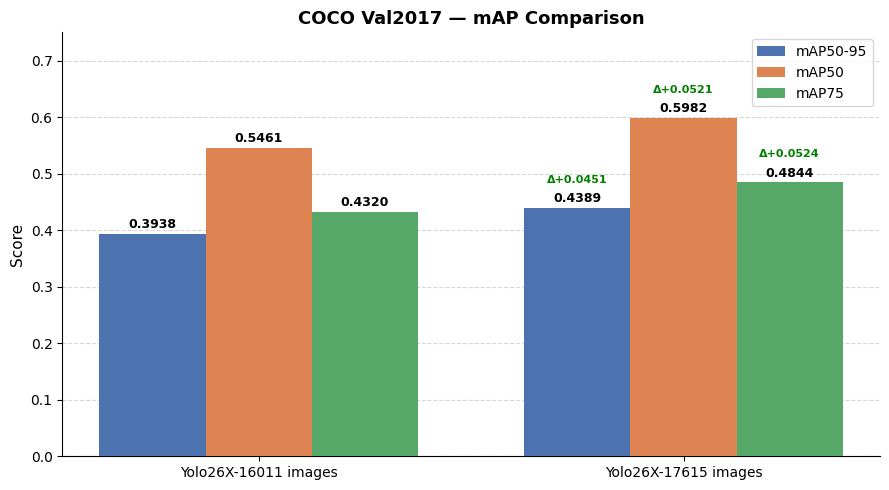

Saved to map_comparison.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ── Results ────────────────────────────────────────────────
models = ["Yolo26X-16011 images", "Yolo26X-17615 images"]

map5095 = [0.3938, 0.4389]
map50   = [0.5461, 0.5982]
map75   = [0.4320, 0.4844]

metrics = {"mAP50-95": map5095, "mAP50": map50, "mAP75": map75}

x = np.arange(len(models))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(9, 5))

for i, (label, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i * width, values, width, label=label, color=colors[i], zorder=3)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

# Delta annotations
for i, (label, values) in enumerate(metrics.items()):
    delta = values[1] - values[0]
    ax.annotate(
        f"Δ+{delta:.4f}",
        xy=(1 + i * width, values[1]),
        xytext=(0, 18), textcoords="offset points",
        ha="center", fontsize=8, color="green", fontweight="bold"
    )

ax.set_xticks(x + width)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 0.75)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("COCO Val2017 — mAP Comparison", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("map_comparison.png", dpi=150)
plt.show()
print("Saved to map_comparison.png")

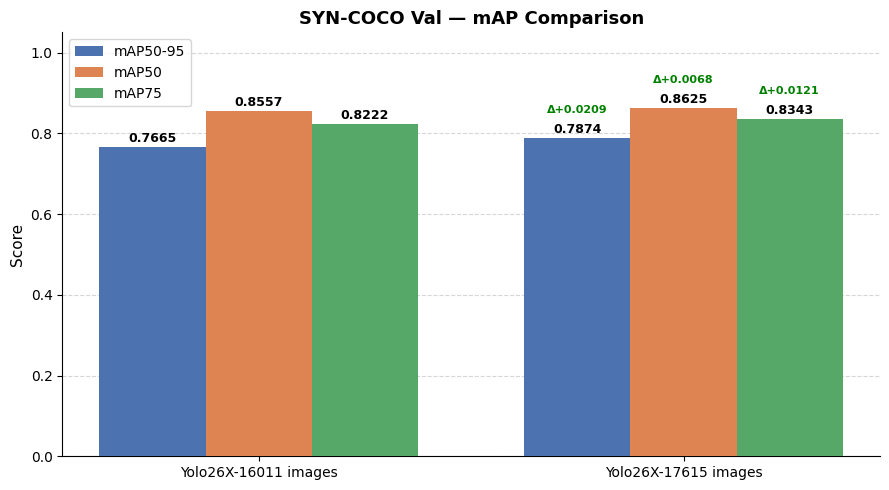

Saved to syn_map_comparison.png


In [33]:

import matplotlib.pyplot as plt
import numpy as np

models = ["Yolo26X-16011 images", "Yolo26X-17615 images"]

map5095 = [0.7665, 0.7874]
map50   = [0.8557, 0.8625]
map75   = [0.8222, 0.8343]

metrics = {"mAP50-95": map5095, "mAP50": map50, "mAP75": map75}

x = np.arange(len(models))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(9, 5))

for i, (label, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i * width, values, width, label=label, color=colors[i], zorder=3)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

for i, (label, values) in enumerate(metrics.items()):
    delta = values[1] - values[0]
    ax.annotate(
        f"Δ+{delta:.4f}",
        xy=(1 + i * width, values[1]),
        xytext=(0, 18), textcoords="offset points",
        ha="center", fontsize=8, color="green", fontweight="bold"
    )

ax.set_xticks(x + width)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("SYN-COCO Val — mAP Comparison", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("syn_map_comparison.png", dpi=150)
plt.show()
print("Saved to syn_map_comparison.png")
